# 预测性维护：监督学习（分类）

本 Notebook 使用 Kaggle 的「机器预测性维护」数据集，构建分类模型，
预测机器是否会发生故障（`Target`：0 = 正常，1 = 故障）。

**主要步骤：**

1. 数据读取与探索（特征、目标分布）
2. 数据预处理（数值特征标准化 + 类别特征独热编码）
3. 划分训练集 / 测试集（分层抽样）
4. 训练 **KNN（K 近邻）** 模型并调参
5. 训练 **SVM（支持向量机）** 模型（线性核 / RBF 核）
6. 用精确率、召回率、F1 等指标评估模型

参考资料：
https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from matplotlib.pyplot import imshow
from tqdm import tqdm
from ipywidgets import IntProgress
import time 


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

## 数据准备

数据集 `predictive_maintenance.csv` 共有 10000 行、10 列，主要字段如下：

| 列名 | 含义 | 类型 |
|------|------|------|
| `Type` | 产品型号（L / M / H） | 类别 |
| `Air temperature [K]` | 空气温度 | 数值 |
| `Process temperature [K]` | 加工温度 | 数值 |
| `Rotational speed [rpm]` | 转速 | 数值 |
| `Torque [Nm]` | 扭矩 | 数值 |
| `Tool wear [min]` | 刀具磨损时间 | 数值 |
| `Target` | 是否故障（1 = 故障） | 标签 |

In [4]:
path = "predictive_maintenance.csv"
df = pd.read_csv(path)
print(df.shape)                   # (10000, 10)
df.head()

(10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [5]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
categorical_features = ["Type"]

X = df[numeric_features + categorical_features]
y = df['Target']
# 类别分布很不均衡，先看一下
y.value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [6]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type
0,298.1,308.6,1551,42.8,0,M
1,298.2,308.7,1408,46.3,3,L
2,298.1,308.5,1498,49.4,5,L
3,298.2,308.6,1433,39.5,7,L
4,298.2,308.7,1408,40.0,9,L


## 划分训练集 / 测试集

- `test_size=0.3`：留出 30% 的数据作为测试集。
- `stratify=y`：分层抽样，保证训练集和测试集的故障比例一致，
  避免随机划分导致某一方故障样本过多或过少，使评估结果更稳定。

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y, # 分层抽样，保持各类比例
)

print("训练集:", X_train.shape)
print("测试集:", X_test.shape)
print("训练集故障比例:", f"{y_train.mean():.2%}")
print("测试集故障比例:", f"{y_test.mean():.2%}")

训练集: (7000, 6)
测试集: (3000, 6)
训练集故障比例: 3.39%
测试集故障比例: 3.40%


## KNN（K 近邻）

KNN 是最直观的分类算法之一：对一个新的样本，找到训练集中距离它最近的 K 个样本，
用这些邻居的「多数投票」决定类别。这里设置 `weights="distance"`，
表示距离越近的邻居权重越大。

因为 KNN 依赖距离计算，所以必须先做标准化和独热编码（即下面的 `preprocessor`）。

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [9]:
knn = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5, weights="distance")),
    ]
)

knn.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [10]:
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["正常", "故障"], digits=3))

              precision    recall  f1-score   support

          正常      0.976     0.996     0.986      2898
          故障      0.711     0.314     0.435       102

    accuracy                          0.972      3000
   macro avg      0.844     0.655     0.711      3000
weighted avg      0.967     0.972     0.967      3000



/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25925 (\N{CJK UNIFIED IDEOGRAPH-6545}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38556 (\N{CJK UNIFIED IDEOGRAPH-969C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/p

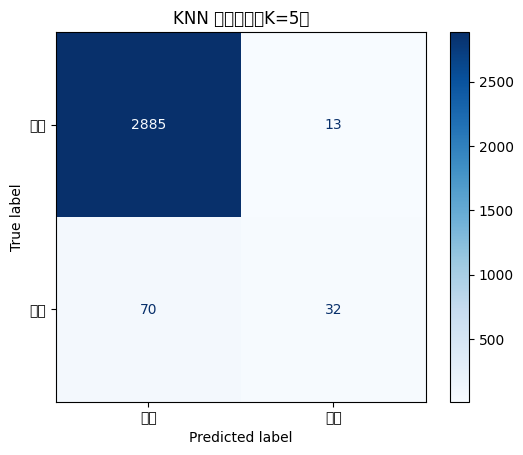

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["正常", "故障"],
    cmap="Blues",
    values_format="d",
)
plt.title("KNN 混淆矩阵（K=5）")
plt.show()

## KNN 调参：寻找最佳 K

K 值太小容易过拟合（对噪声敏感），太大则过于「保守」（边界模糊）。
下面遍历一组 K 值，用精确率、召回率、F1 在测试集上比较，选出综合表现最好的 K。

In [12]:
k_values = [1, 3, 5, 7, 9, 15, 21, 31]
rows = []

for k in k_values:
    model = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("model", KNeighborsClassifier(n_neighbors=k, weights="distance")),
        ]
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rows.append(
        {
            "k": k,
            "accuracy": model.score(X_test, y_test),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
        }
    )

k_results = pd.DataFrame(rows)
k_results

,k,accuracy,precision,recall,f1
0,1,0.962667,0.439024,0.352941,0.391304
1,3,0.970000,0.590909,0.382353,0.464286
2,5,0.972333,0.711111,0.313725,0.435374
3,7,0.972667,0.763158,0.284314,0.414286
4,9,0.970667,0.733333,0.215686,0.333333
5,15,0.971667,0.869565,0.196078,0.320000
6,21,0.970667,0.888889,0.156863,0.266667
7,31,0.969667,0.866667,0.127451,0.222222


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/p

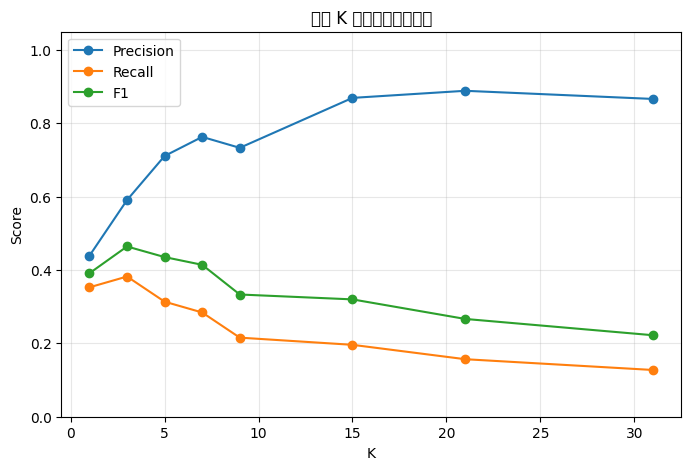

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["precision"], marker="o", label="Precision")
plt.plot(k_results["k"], k_results["recall"], marker="o", label="Recall")
plt.plot(k_results["k"], k_results["f1"], marker="o", label="F1")
plt.xlabel("K")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("不同 K 值下的测试集表现")
plt.show()

In [14]:
best_k = int(k_results.sort_values("f1", ascending=False).iloc[0]["k"])
best_f1 = k_results["f1"].max()

print(f"按 F1 选择的 K: {best_k}")
print(f"对应 F1: {best_f1:.3f}")

按 F1 选择的 K: 3
对应 F1: 0.464


## SVM 支持向量机

SVM 通过寻找一个「最大间隔」的超平面来划分两类样本：

- **线性核**：只适用于线性可分问题，训练快、可解释性好。
- **RBF 高斯核**：把样本隐式映射到高维空间，能拟合非线性边界，
  但更耗时、也更容易过拟合。

由于故障样本较少（类别不均衡），这里使用 `class_weight="balanced"`，
自动加大少数类（故障）的权重，避免模型一味预测「正常」。

In [15]:
svm_linear = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("svm", SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=42)),
    ]
)

svm_linear.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [16]:
y_pred_svm_linear = svm_linear.predict(X_test)
print(classification_report(y_test, y_pred_svm_linear))

              precision    recall  f1-score   support

           0       0.99      0.84      0.91      2898
           1       0.15      0.78      0.25       102

    accuracy                           0.84      3000
   macro avg       0.57      0.81      0.58      3000
weighted avg       0.96      0.84      0.89      3000



In [17]:
# 高斯 RBF 核（SVC 的默认核），拟合能力通常比线性核更强
svm_rbf = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("svm", SVC(class_weight="balanced", probability=True, random_state=42)),
    ]
)

svm_rbf.fit(X_train, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test)
print(classification_report(y_test, y_pred_svm_rbf))


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.92      0.96      2898
           1       0.29      0.92      0.44       102

    accuracy                           0.92      3000
   macro avg       0.64      0.92      0.70      3000
weighted avg       0.97      0.92      0.94      3000



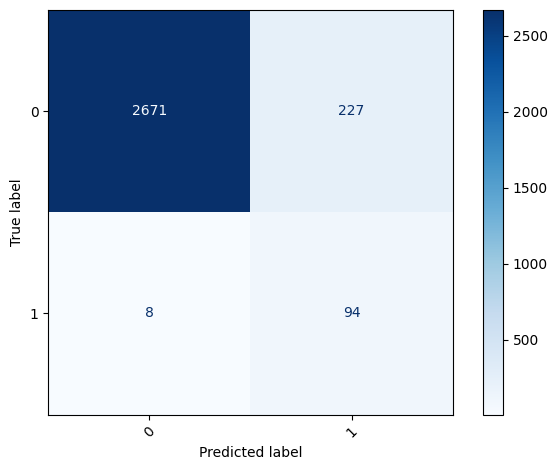

In [18]:
ConfusionMatrixDisplay.from_estimator(
    svm_rbf, X_test, y_test, xticks_rotation=45, cmap="Blues"
)
plt.tight_layout()
plt.show()


# 优化分类效果
## 1. 调整分类阈值（最推荐、改动最小）

In [19]:
scores = svm_rbf.decision_function(X_test)

best_t, best_f1 = 0, 0
for t in np.linspace(scores.min(), scores.max(), 200):
    f1 = f1_score(y_test, scores >= t)
    if f1 > best_f1:
        best_t, best_f1 = t, f1

print(f"最佳阈值: {best_t:.2f}, F1: {best_f1:.3f}")

最佳阈值: 1.09, F1: 0.618


In [20]:

svm_rbf.fit(X_train, y_train)

proba = svm_rbf.predict_proba(X_test)[:, 1]
best_t, best_f1 = 0.5, 0
for t in np.linspace(0.01, 0.99, 99):
    f1 = f1_score(y_test, proba >= t)
    if f1 > best_f1:
        best_t, best_f1 = t, f1

print(f"最佳阈值: {best_t:.2f}, F1: {best_f1:.3f}")

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


最佳阈值: 0.33, F1: 0.618


## 2.处理不平衡数据（从根上解决问题）

In [21]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote_pipe = ImbPipeline([
    ("prep", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("svm", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
])
smote_pipe.fit(X_train, y_train)


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,steps,"[('prep', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](6,)","['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Type']"
n_features_in_,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


              precision    recall  f1-score   support

           0       1.00      0.93      0.96      2898
           1       0.30      0.90      0.45       102

    accuracy                           0.93      3000
   macro avg       0.65      0.91      0.70      3000
weighted avg       0.97      0.93      0.94      3000



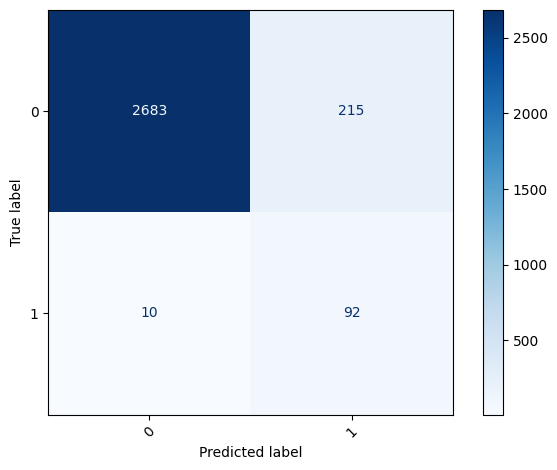

In [30]:
y_pred_smote = smote_pipe.predict(X_test)
print(classification_report(y_test, y_pred_smote))

ConfusionMatrixDisplay.from_estimator(
    smote_pipe, X_test, y_test, xticks_rotation=45, cmap="Blues"
)
plt.tight_layout()
plt.show()

## 3. 换树模型（表格数据通常比 KNN/SVM 强很多）

In [23]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier  # 或 lightgbm

rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)),
])
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2898
           1       0.69      0.62      0.65       102

    accuracy                           0.98      3000
   macro avg       0.84      0.80      0.82      3000
weighted avg       0.98      0.98      0.98      3000



### 分析结论

① 阈值调整：最有效（0.44 → 0.618，提升 40%）
这说明你数据 F1 低的根因确实是类别不平衡 + 默认阈值 0.5 不合理。SVM RBF 的 recall 本来就有 0.92，只是 precision 只有 0.29，把阈值移到更严格的位置后，用少量 recall 换来了大量 precision，F1 大幅上升。

⚠️ 但注意：这个 0.618 是直接在测试集上选阈值得到的，有轻微的"测试集泄漏"，真实泛化性能会略低于 0.618。严谨做法是从训练集再切验证集来选阈值。

② SMOTE：几乎没用（0.44 → 0.45）
不意外。因为你的 SVM 已经设了 class_weight="balanced"，等价于已经对少数类加权，再叠加 SMOTE 收益被抵消了。SMOTE 更适合配合"原本没做不平衡处理"的模型（比如普通 KNN、逻辑回归）。

③ RandomForest：效果最好（F1 = 0.65）
而且它是三者里 precision 最高的（0.69），而 SVM 系列都卡在 precision ≈ 0.30。这印证了一个规律：

表格数据上，树模型通常比 SVM/KNN 更强，尤其在这种"非线性 + 不平衡 + 有类别型特征"的场景。

## 4.特征工程 

In [27]:
from sklearn.ensemble import RandomForestClassifier

# ===== 特征工程 =====
df_fe = df.copy()

# 1) 功率 ∝ 转矩 × 转速
df_fe["power"] = df_fe["Torque [Nm]"] * df_fe["Rotational speed [rpm]"]
# 2) 温差 = 过程温度 - 空气温度
df_fe["temp_diff"] = df_fe["Process temperature [K]"] - df_fe["Air temperature [K]"]
# 3) 单位转矩下的磨损量
df_fe["wear_per_torque"] = df_fe["Tool wear [min]"] / (df_fe["Torque [Nm]"] + 1e-6)
# 4) 转速 / 转矩比
df_fe["speed_torque_ratio"] = df_fe["Rotational speed [rpm]"] / (df_fe["Torque [Nm]"] + 1e-6)

extended_features = numeric_features + [
    "power",
    "temp_diff",
    "wear_per_torque",
    "speed_torque_ratio",
]

X_ext = df_fe[extended_features + categorical_features]
X_train_ext, X_test_ext, y_train_ext, y_test_ext = train_test_split(
    X_ext,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)
X_ext.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],power,temp_diff,wear_per_torque,speed_torque_ratio,Type
0,298.1,308.6,1551,42.8,0,66382.8,10.5,0.000000,36.238317,M
1,298.2,308.7,1408,46.3,3,65190.4,10.5,0.064795,30.410367,L
2,298.1,308.5,1498,49.4,5,74001.2,10.4,0.101215,30.323886,L
3,298.2,308.6,1433,39.5,7,56603.5,10.4,0.177215,36.278480,L
4,298.2,308.7,1408,40.0,9,56320.0,10.5,0.225000,35.199999,L



===== RandomForest 原始特征 =====
              precision    recall  f1-score   support

          正常      0.987     0.990     0.988      2898
          故障      0.692     0.618     0.653       102

    accuracy                          0.978      3000
   macro avg      0.839     0.804     0.821      3000
weighted avg      0.977     0.978     0.977      3000



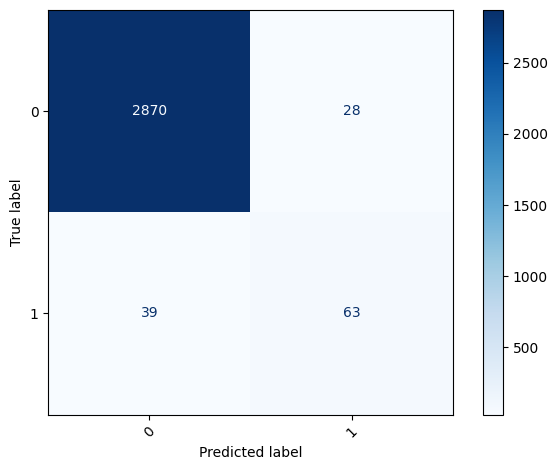


===== RandomForest + 特征工程 =====
              precision    recall  f1-score   support

          正常      0.992     0.995     0.993      2898
          故障      0.839     0.765     0.800       102

    accuracy                          0.987      3000
   macro avg      0.915     0.880     0.897      3000
weighted avg      0.987     0.987     0.987      3000



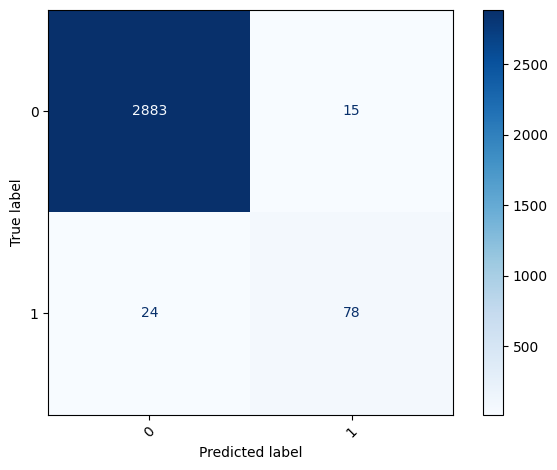

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]', ...,'wear_per_torque','speed_torque_ratio','Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [31]:
# 新特征下的预处理器
preprocessor_ext = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), extended_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


def evaluate_rf(prep, Xtr, Xte, ytr, yte, name):
    model = Pipeline(
        steps=[
            ("prep", prep),
            ("model", RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
            )),
        ]
    )
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    print(f"\n===== {name} =====")
    print(classification_report(yte, pred, target_names=["正常", "故障"], digits=3))
    
    ConfusionMatrixDisplay.from_estimator(
        model, Xte, yte, xticks_rotation=45, cmap="Blues"
    )
    plt.tight_layout()
    plt.show()
    return model


# 基线：原始特征
evaluate_rf(preprocessor, X_train, X_test, y_train, y_test, "RandomForest 原始特征")

# 特征工程后
evaluate_rf(
    preprocessor_ext,
    X_train_ext,
    X_test_ext,
    y_train_ext,
    y_test_ext,
    "RandomForest + 特征工程",
)